# Part A: Basic Prescriptive Analytics

In [ ]:
!pip install pyspark shapely pandas geopandas matplotlib seaborn numpy geopy

In [7]:
# imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, unix_timestamp, avg, hour, count, round
from pyspark.sql.types import TimestampType
from shapely.geometry import Point

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Data Ingestion

In [8]:
#display(dbutils.fs.ls("dbfs:/FileStore/tables/"))

In [9]:
# a) initialize spark session
spark = SparkSession.builder.appName("NYC Taxi Data").getOrCreate()

# b) load dataset
df1 = spark.read.format("csv").option("header", "true").load("yellow_tripdata_2015-01.csv").limit(25000) #25000 so that everything runs faster
df2 = spark.read.format("csv").option("header", "true").load("yellow_tripdata_2016-01.csv").limit(25000)
df3 = spark.read.format("csv").option("header", "true").load("yellow_tripdata_2016-02.csv").limit(25000)
df4 = spark.read.format("csv").option("header", "true").load("yellow_tripdata_2016-03.csv").limit(25000)

df = df1.union(df2)
df = df.union(df3)
df = df.union(df4)

In [10]:
df.count()

100000

### Initial Data Exploration

In [11]:
# a) schema
df.count()
df.show(5)
df.columns
df.printSchema()
df.describe().show()

# b) basic stats
df.select("trip_distance", "passenger_count", "fare_amount").describe().show()

+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|   pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag|  dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       2| 2015-01-15 19:05:39|  2015-01-15 19:23:42|              1|         1.59|   -73.993896484375|40.750110626220703|        

### Data Cleaning

In [12]:
# a) handle missing values
df = df.dropna(subset=["fare_amount", "trip_distance", "passenger_count"])

# b) filter out rows w/ invalid data
df = df.filter((col("fare_amount") >= 0) & (col("trip_distance") > 0))

# c) convert `pickup_datetime` and `dropoff_datetime` to timestamp
df = df.withColumn("tpep_pickup_datetime", col("tpep_pickup_datetime").cast(TimestampType())) \
       .withColumn("tpep_dropoff_datetime", col("tpep_dropoff_datetime").cast(TimestampType()))

# d) create new columns (trip duration in min, trip speed in mph)
## trip duration in min
df = df.withColumn("trip_duration_exact",
                   (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60)

df = df.withColumn("trip_duration_mins", df["trip_duration_exact"].cast("int"))


## trip speed in mph
df = df.withColumn("trip_speed_mph",
                   col("trip_distance") / (col("trip_duration_mins") / 60))

## display
df.select("tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "trip_duration_exact", "trip_duration_mins", "trip_speed_mph").show()

+--------------------+---------------------+-------------+-------------------+------------------+------------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|trip_duration_exact|trip_duration_mins|    trip_speed_mph|
+--------------------+---------------------+-------------+-------------------+------------------+------------------+
| 2015-01-15 19:05:39|  2015-01-15 19:23:42|         1.59|              18.05|                18| 5.300000000000001|
| 2015-01-10 20:33:38|  2015-01-10 20:53:28|         3.30| 19.833333333333332|                19|10.421052631578947|
| 2015-01-10 20:33:38|  2015-01-10 20:43:41|         1.80|              10.05|                10|              10.8|
| 2015-01-10 20:33:39|  2015-01-10 20:52:58|         3.00| 19.316666666666666|                19| 9.473684210526317|
| 2015-01-10 20:33:39|  2015-01-10 20:53:52|         9.00| 20.216666666666665|                20|              27.0|
| 2015-01-10 20:33:39|  2015-01-10 20:58:31|         2.20| 24.86

### Exploratory Data Analysis

In [13]:
# a) calculate avg fare and avg trip distance grouped by num of passengers
print('F1: Average Trip Distance and Fare Amount by Passenger Count\n')
df.groupBy("passenger_count") \
  .agg(avg("fare_amount").alias("avg_fare"), avg("trip_distance").alias("avg_trip_distance")) \
  .orderBy("passenger_count") \
  .show()

# b) busiest times of day for taxi pickup
print('F2: Taxi Usage by Time of Day (hour)\n')
df.groupBy(hour("tpep_pickup_datetime").alias("hour")) \
  .agg(count("*").alias("pickup_count")) \
  .orderBy("pickup_count", ascending=False) \
  .show()


F1: Average Trip Distance and Fare Amount by Passenger Count

+---------------+------------------+------------------+
|passenger_count|          avg_fare| avg_trip_distance|
+---------------+------------------+------------------+
|              0| 9.090909090909092|1.7090909090909094|
|              1| 14.04878511195115| 3.515097799747983|
|              2|14.383493387246231| 3.626421531463237|
|              3|14.167116598079561|3.5640850480109716|
|              4|14.407798165137615| 3.624094036697248|
|              5|14.058589967073408|3.5048285880302186|
|              6|13.986577181208053| 3.482803538743135|
+---------------+------------------+------------------+

F2: Taxi Usage by Time of Day (hour)

+----+------------+
|hour|pickup_count|
+----+------------+
|  21|       16969|
|   8|        9311|
|   7|        8197|
|   1|        7370|
|   2|        5750|
|   3|        4623|
|  20|        4542|
|   9|        3944|
|   0|        3132|
|  19|        1499|
|  18|        1214|
|  

In [15]:
# c) neighbourhoods w/ highest average fare amount

## ZIP codes
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="databricks_geocoder")

def get_postal_code(lat, lon):
    try:
        location = geolocator.reverse(f"{lat}, {lon}", language="en", timeout=10)
        time.sleep(1)
        if location and "postcode" in location.raw["address"]:
            return location.raw["address"]["postcode"]
        else:
            return None
    except Exception as e:
        return None

## only works with ~10 otherwise crashes. IF CRASHES with ConnectionRefusedError or similar, restart VScode
df_sample = df.limit(10)
df_gpd = df_sample.toPandas()
df_gpd["ZIPCode"] = df_gpd.apply(lambda row: get_postal_code(row["pickup_latitude"], row["pickup_longitude"]), axis=1)

df_gpd_spark = spark.createDataFrame(df_gpd)

df_avg_fare_by_ZIP = df_gpd_spark.groupBy("ZIPCode", "pickup_latitude", "pickup_longitude") \
    .agg({"fare_amount": "avg"}) \
    .withColumnRenamed("avg(fare_amount)", "avg_fare_amount")

df_sorted = df_avg_fare_by_ZIP.orderBy(df_avg_fare_by_ZIP.avg_fare_amount.desc())
print('F3: Average Fare (USD) by ZIP Code\n')
df_sorted.show(10)

## alt method using GeoJSON file
#dbutils.fs.cp("dbfs:/FileStore/tables/NYC_Taxi_Zones.geojson", "file:/geo/geodata.json")
nbhds_gdf = gpd.read_file("NYC Taxi Zones.geojson")[["zone", "geometry"]]

### VScode memory issues cause limit to be ~ 1000. (not useable); can be run on Databricks with no issue
pandas_df = df.select("pickup_longitude", "pickup_latitude", "fare_amount").limit(1000).toPandas()
pandas_df['geometry'] = [Point(xy) for xy in zip(pandas_df.pickup_longitude, pandas_df.pickup_latitude)]
trips_gdf = gpd.GeoDataFrame(pandas_df, geometry='geometry', crs="EPSG:4326")

joined_gdf = gpd.sjoin(trips_gdf, nbhds_gdf, how="left", predicate="intersects")

joined_df_spark = SparkSession.builder.getOrCreate().createDataFrame(joined_gdf.drop(columns='geometry'))
joined_df_spark = joined_df_spark.withColumn("fare_amount", col("fare_amount").cast("double"))
avg_fare_df = joined_df_spark.groupBy("zone").avg("fare_amount").orderBy("avg(fare_amount)", ascending=False)

print('F4: Average Fare by Neighbourhood\n')
avg_fare_df.show()

F3: Average Fare (USD) by ZIP Code

+-------+------------------+-------------------+---------------+
|ZIPCode|   pickup_latitude|   pickup_longitude|avg_fare_amount|
+-------+------------------+-------------------+---------------+
|  11430|40.644355773925781|-73.783042907714844|           52.0|
|  11371|  40.7740478515625|-73.874374389648438|           27.0|
|  10022|40.760448455810547|-73.973945617675781|           19.0|
|  10022|40.762428283691406|-73.971176147460938|           15.0|
|  10012|  40.7242431640625| -74.00164794921875|           14.5|
|  10009|40.726009368896484|  -73.9832763671875|           14.0|
|  10001|40.750110626220703|   -73.993896484375|           12.0|
|  10025|40.802787780761719|-73.963340759277344|            9.5|
|  10119|40.751419067382812|-73.993782043457031|            7.5|
|  10014|40.731777191162109|-74.006721496582031|            6.0|
+-------+------------------+-------------------+---------------+

F4: Average Fare by Neighbourhood

+-----------------

In [19]:
#%fs ls dbfs:/FileStore/tables/NYC_Taxi_Zones.geojson

In [18]:
#%fs ls dbfs:/FileStore/tables/

### Visualizing the Data

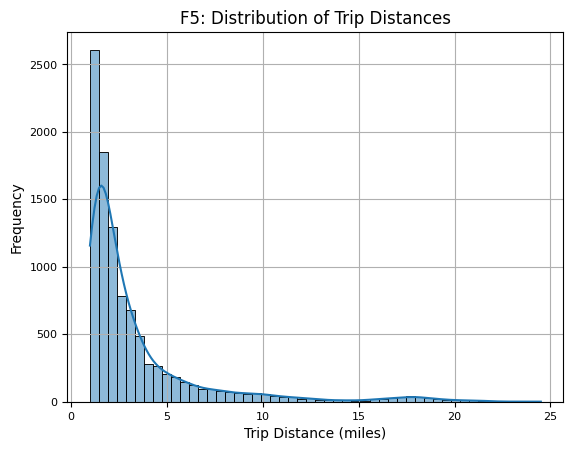

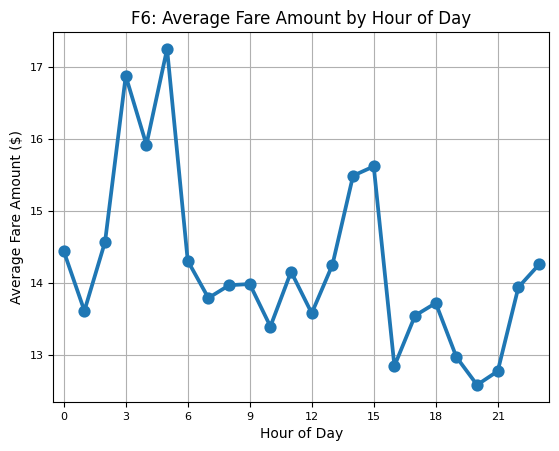

In [16]:
# pandas df for visualization purposes
pandas_df = df.select("trip_distance", "fare_amount", "tpep_pickup_datetime").limit(10000).toPandas()

# a) distribution plot of trip distances
pandas_df['trip_distance'] = pd.to_numeric(pandas_df['trip_distance'], errors='coerce')
pandas_df = pandas_df.dropna(subset=['trip_distance'])
filtered_df = pandas_df[pandas_df['trip_distance'] <= 25]

ax = sns.histplot(data=filtered_df, x='trip_distance', bins=50, kde=True)

plt.title('F5: Distribution of Trip Distances', fontsize=12)
plt.xlabel('Trip Distance (miles)', fontsize=10) 
plt.ylabel('Frequency', fontsize=10)

plt.yticks(fontsize=8)
plt.xticks(fontsize=8)

plt.grid(True)
plt.show()

# b) average fares by hour of day
pandas_df['tpep_pickup_datetime'] = pd.to_datetime(pandas_df['tpep_pickup_datetime'])
pandas_df['fare_amount'] = pd.to_numeric(pandas_df['fare_amount'], errors='coerce')
pandas_df['hour'] = pandas_df['tpep_pickup_datetime'].dt.hour
avg_fph = pandas_df.groupby('hour')['fare_amount'].mean().reset_index()
avg_fph.columns = ['Hour of Day', 'Average Fare Amount']

sns.pointplot(data=avg_fph, x='Hour of Day', y='Average Fare Amount')

plt.title('F6: Average Fare Amount by Hour of Day', fontsize=12)
plt.xlabel('Hour of Day', fontsize=10)
plt.ylabel('Average Fare Amount ($)', fontsize=10)

plt.xticks(ticks=[0, 3, 6, 9, 12, 15, 18, 21], fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()

### Summary and Insights

This analysis aims to summarize key insights from the analysis based on peak taxi usage times, distance and fare patterns, as well as geography and fare distribution.

**Taxi Usage by Time of Day (F2)**

The analysis of taxi pickup times and hour of day revealed that taxis were high in demand during the evening hours. The data shows that the peak hour of pickups was at 7 PM (19:00), at 603,362 people. This peak in demand can be linked to many social activities which could include entertainment, dining, and evening commute from work/school. The top 7 hours ranged from 5-11 PM. Off-peak hours consisted of early morning and afternoon, with the lowest pickup count recorded at 2 AM at 218,905 people. The drop in pickups can be reasoned by people being busy with work, sleep, or using an alternate commute service (i.e. public transit). The difference in pickup volume shows a clear difference between peak and off-peak commute hours. 

**Average Trip Distance and Fare Amount (F1)**

The analysis shows that most trips range 3 miles on average across 3 to 7 passengers, indicating an abundance of intra-city travel which makes sense considering city travel patterns. The highest outlying trip distances average at around 19, and 23 miles for 1 and 2 passengers respectively, a stark difference when compared to the 3 mile average that most trips last. This can be explained through reasons including long distance travel (airport transfers) or out of city trips. Larger passenger counts of 8 or 9 resulted in slightly longer trip distances again, measured at 7 and 15 miles respectively– a number suggesting large group trips using specialized/bigger vehicles for travel.

The fare stays consistent from 1 to 7 passengers averaging around $13, while it jumps at 8 to 9 passengers at a sum of $33 and $69, indicating that large groups often travel over longer distances, the vehicles needed for transportation are larger/more specialized to accommodate them and additional fees that transporting more passengers carry. The 0 passenger trips can be explained by an error or a non-passenger trip, such as delivery or driving to pick up a passenger. These trips can also include maintenance runs or administrative work, resulting in no passengers present. The fees and distances associated with these trips can also be explained similarly, as these reasons present lower costs and lower distances.

Longer trips with a higher fare result in both ends of the distribution which can indicate a few things. First being that low passenger counts and long distances are due to some specific circumstance, such as a trip to/from the airport, or long distance commutes (possibly work). The second being high passenger counts, which as previously mentioned result in higher cost and longer distances due to special transportation needs, which cost more. The overall data suggests that on average, a taxi ride is short and affordable, with the outlying data being the result of specific cases discussed above. 

**Geographical Patterns in Taxi Usage and Fares (F3, F4)**

Through analyzing the geographical distribution of popular taxi pick-up zones, we found that the neighborhood around Baisley Park and the JFK Airport, located in Queens (11430 ZIP code) had the highest average fare amounts at $43 to $52. The high fare and location indicate that the trips are more costly due to the distance that needs to be traveled, as they are generally further away from the city center or downtown areas. This is the same reason the second highest fare ($27) was around LaGuardia Airport in the East Elmhurst neighborhood of Queens (11371 ZIP code). Moderate-fare neighborhoods with fares of $19 and $14 included Midtown East (10022 ZIP code) and Greenwich Village (10012 ZIP code) respectively, which have more residential areas. The Low-fare neighborhoods included Penn Station in New York and West Village in Lower Manhattan. at $7.5 and $6 again, due to neighborhood structures. Penn station is one of the busiest transportation facilities, where it makes sense for taxis to be low in demand, and to have lower fees since most trips would be to and from the station very locally. West village has low fares due to the close proximity to many attractions, leaving less need for taxis and shorter trips when taken. 

**Conclusion**

This taxi analysis reveals insightful information such as the demand, distribution and peak times of taxi usage in New York. We see that peak times are in the evening from 5-11 PM, where off-peak hours are late nights and early mornings. Trip distance and fare patterns suggest that taxis are most frequently used for intra-city trips, but some outliers should be noted, as frequent longer trips are usually towards airports and result in a higher fare. Through understanding the relationship between these factors, more informed and insightful decisions can be made on pricing, and usage of taxis. 


# Part B: Advanced Prescriptive Analytics:

*Feature Engineering – Compute the following “extraction of new useful features”*

### 1. Trip Duration
This question was already done in part A. Results are visible below:

In [17]:
df.select("trip_duration_mins").show()

+------------------+
|trip_duration_mins|
+------------------+
|                18|
|                19|
|                10|
|                19|
|                20|
|                24|
|                37|
|                 9|
|                29|
|                 5|
|                26|
|                15|
|                22|
|                14|
|                14|
|                25|
|                 6|
|                16|
|                 8|
|                10|
+------------------+
only showing top 20 rows



### 2. Hour and Day

In [0]:
df = df.withColumn("pickup_day", dayofmonth("tpep_pickup_datetime").cast("int"))
df = df.withColumn("pickup_hour", hour("tpep_pickup_datetime").cast("int"))

In [0]:
df.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'pickup_longitude',
 'pickup_latitude',
 'RateCodeID',
 'store_and_fwd_flag',
 'dropoff_longitude',
 'dropoff_latitude',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'trip_duration_exact',
 'trip_duration_mins',
 'trip_speed_mph',
 'pickup_day',
 'pickup_hour']

### 3. Trend Over Years

In [0]:
#We'll create a new column to extract the year of the trip, from the pickup date
#Even if someone calls a taxi during new years countdown (hypothetically), it should still count as a taxi trip from the year they entered the taxi in

In [0]:
df = df.withColumn("pickup_year", year("tpep_pickup_datetime"))

In [0]:
duration_2015_value = df.filter(df["pickup_year"] == 2015).agg(avg("trip_duration_mins")).first()[0]
duration_2016_value = df.filter(df["pickup_year"] == 2016).agg(avg("trip_duration_mins")).first()[0]

In [0]:
print(f"The fare increased by ${duration_2016_value-duration_2015_value} between the years 2015 and 2016 (the only 2 years present in this dataset)")

The fare increased by $2.468667892944369 between the years 2015 and 2016 (the only 2 years present in this dataset)


In [0]:
average_year_duration_df = pd.DataFrame({"Year": [2015, 2016],
                                "Average Trip Duration": [duration_2015_value, duration_2016_value]
                                })

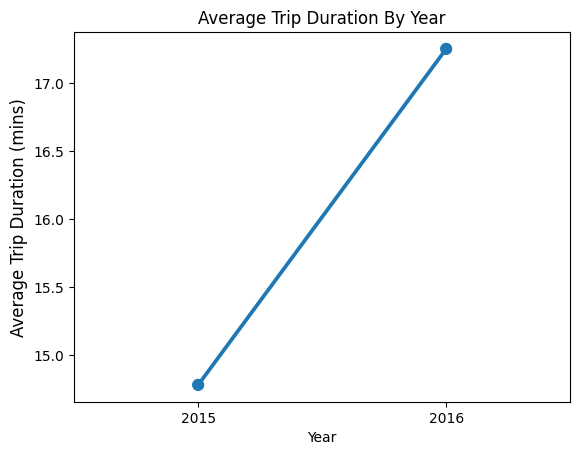

In [0]:
sns.pointplot(data=average_year_duration_df, x="Year", y="Average Trip Duration")

plt.title("Average Trip Duration By Year", fontsize=12)
plt.xlabel("Year", fontsize=10)
plt.ylabel("Average Trip Duration (mins)", fontsize=12)

plt.show()

### 4. Hourly Analysis

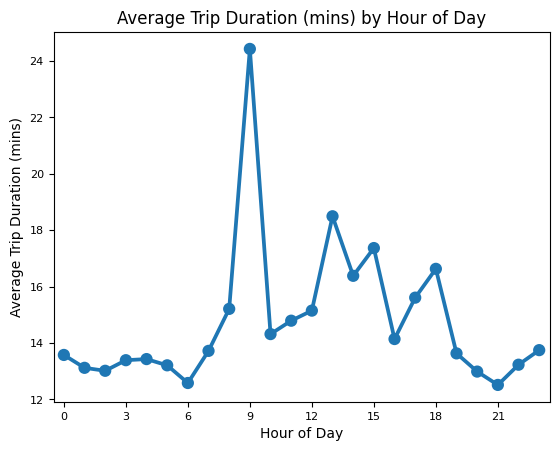

In [0]:
p_df = df.select("trip_duration_mins", "tpep_pickup_datetime").limit(10000).toPandas()


p_df['tpep_pickup_datetime'] = pd.to_datetime(p_df['tpep_pickup_datetime'])
p_df['hour'] = p_df['tpep_pickup_datetime'].dt.hour
avg_dph = p_df.groupby('hour')['trip_duration_mins'].mean().reset_index()
avg_dph.columns = ['Hour of Day', 'Average Trip Duration']

sns.pointplot(data=avg_dph, x='Hour of Day', y='Average Trip Duration')

plt.title('Average Trip Duration (mins) by Hour of Day', fontsize=12)
plt.xlabel('Hour of Day', fontsize=10)
plt.ylabel('Average Trip Duration (mins)', fontsize=10)

plt.xticks(ticks=[0, 3, 6, 9, 12, 15, 18, 21], fontsize=8)
plt.yticks(fontsize=8)

plt.show()

You can see that between 9 and 10am is definitely rush hour for NYC.
There is another spike at 1pm-2pm where many people may go out for lunch/go back home to eat
And another spike at 6pm-7pm where many people are heading home from work

### 5. Identify Hotspots

In [0]:
df = df.withColumn('pickup_longitude', df["pickup_longitude"].cast("double"))
df = df.withColumn('pickup_latitude', df["pickup_latitude"].cast("double"))

In [0]:
#accuracy to 11.1m
#(https://support.garmin.com/en-CA/?faq=hRMBoCTy5a7HqVkxukhHd8)
df = df.withColumn('pickup_longitude', round(df["pickup_longitude"], 4))
df = df.withColumn('pickup_latitude', round(df["pickup_latitude"], 4))

In [0]:
df = df.withColumn("lat_and_long", concat(col("pickup_latitude"), lit(", "), col("pickup_longitude")))

In [0]:
df.select("lat_and_long").show()

+-----------------+
|     lat_and_long|
+-----------------+
|40.7501, -73.9939|
|40.7242, -74.0016|
|40.8028, -73.9633|
|40.7624, -73.9712|
| 40.774, -73.8744|
| 40.726, -73.9833|
| 40.6444, -73.783|
|40.7514, -73.9938|
|40.7604, -73.9739|
|40.7318, -74.0067|
|40.7398, -73.9764|
|40.7542, -73.9687|
|40.7696, -73.8631|
|40.7794, -73.9455|
| 40.774, -73.8745|
|40.7519, -73.9766|
|40.7179, -74.0028|
|40.7364, -73.9975|
| 40.824, -73.9523|
|40.7501, -73.9911|
+-----------------+
only showing top 20 rows



In [0]:
lat_and_long_df = df.groupBy("lat_and_long").count()
top_lat_and_long = lat_and_long_df.orderBy("count", ascending=False).limit(10).toPandas()

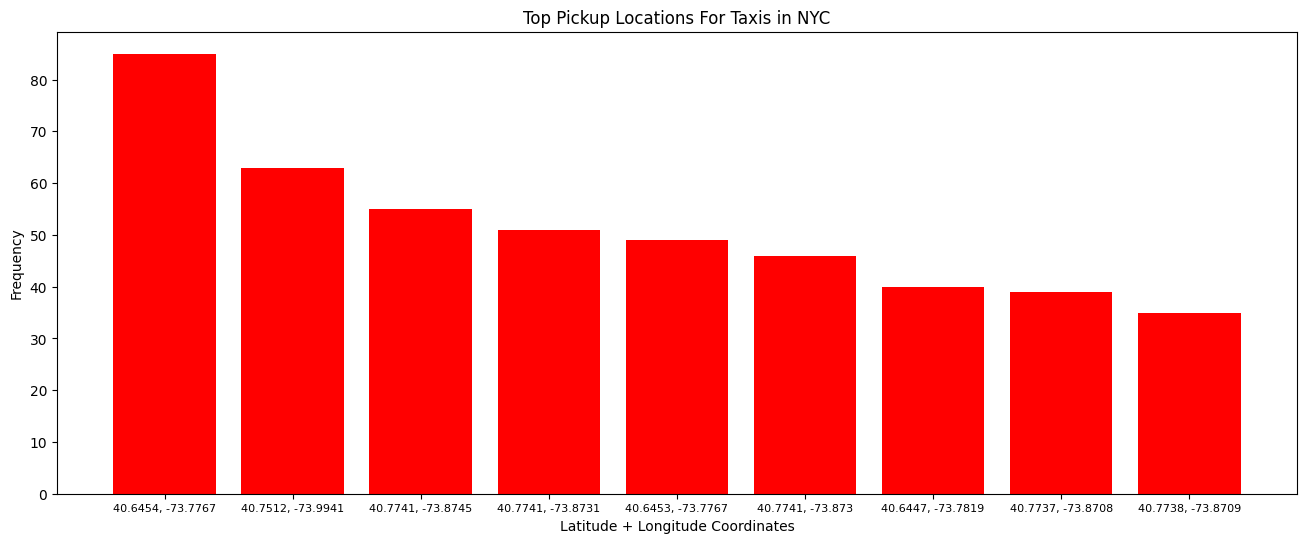

In [0]:
top_lat_and_long["lat_and_long"] = top_lat_and_long["lat_and_long"].astype(str) #From object type to string

plt.figure(figsize=(16, 6))

#We exclude the top value, because the top value is a value of (0, 0), which indicates that it is a placeholder for
#unknown long/lat coordinates
plt.bar(top_lat_and_long["lat_and_long"].tail(9), top_lat_and_long["count"].tail(9), color="red")
plt.title("Top Pickup Locations For Taxis in NYC")
plt.xlabel("Latitude + Longitude Coordinates")
plt.ylabel("Frequency")
plt.xticks(size=8)

plt.show()

Lets do it again for dropoff coordinates

In [0]:
df = df.withColumn('dropoff_longitude', df["dropoff_longitude"].cast("double"))
df = df.withColumn('dropoff_latitude', df["dropoff_latitude"].cast("double"))

df = df.withColumn('dropoff_longitude', round(df["dropoff_longitude"], 4))
df = df.withColumn('dropoff_latitude', round(df["dropoff_latitude"], 4))


In [0]:
df = df.withColumn("lat_and_long_dropoff", concat(col("dropoff_latitude"), lit(", "), col("dropoff_longitude")))

In [0]:
df.select("lat_and_long_dropoff").show()

+--------------------+
|lat_and_long_dropoff|
+--------------------+
|   40.7506, -73.9748|
|   40.7591, -73.9944|
|   40.8244, -73.9518|
|   40.7427, -74.0042|
|    40.7582, -73.987|
|   40.7496, -73.9925|
|   40.7594, -73.9876|
|   40.7572, -73.9674|
|   40.7352, -73.9973|
|   40.7399, -73.9952|
|    40.7579, -73.984|
|   40.7869, -73.9551|
|   40.7858, -73.9527|
|   40.7861, -73.9809|
|   40.7186, -73.9524|
|   40.7146, -73.9989|
|   40.7042, -74.0079|
|   40.7619, -73.9782|
|   40.8111, -73.9533|
|   40.7349, -73.9886|
+--------------------+
only showing top 20 rows



In [0]:
lat_and_long_df_dropoff = df.groupBy("lat_and_long_dropoff").count()
top_lat_and_long_dropoff = lat_and_long_df_dropoff.orderBy("count", ascending=False).limit(10).toPandas()

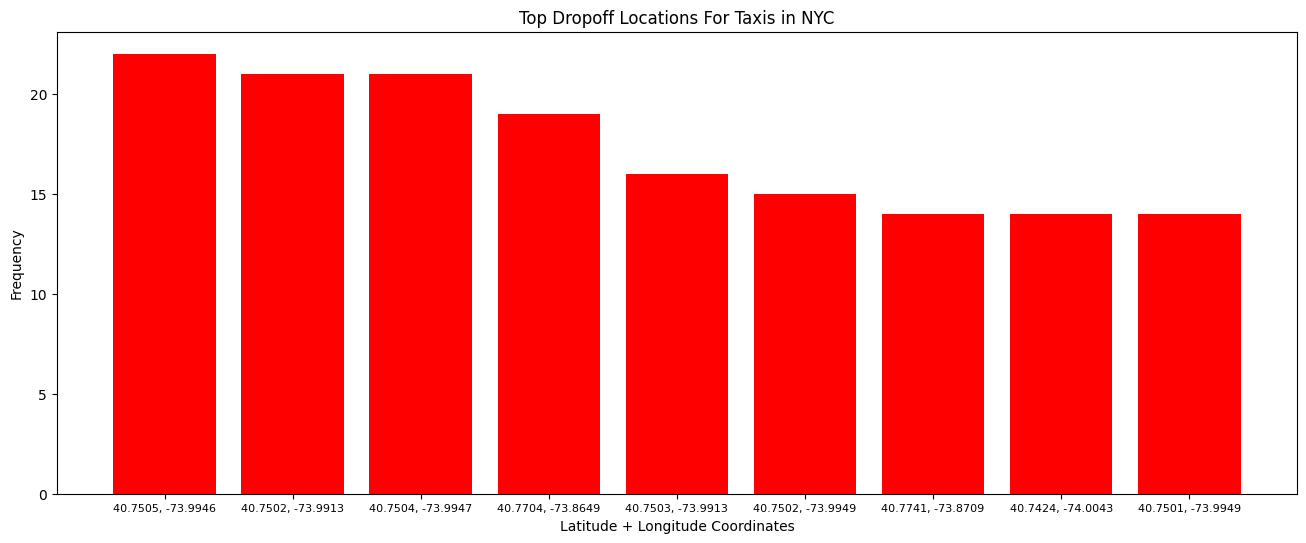

In [0]:
top_lat_and_long_dropoff["lat_and_long_dropoff"] = top_lat_and_long_dropoff["lat_and_long_dropoff"].astype(str) #From object type to string

plt.figure(figsize=(16, 6))

plt.bar(top_lat_and_long_dropoff["lat_and_long_dropoff"].tail(9), top_lat_and_long_dropoff["count"].tail(9), color="red")
plt.title("Top Dropoff Locations For Taxis in NYC")
plt.xlabel("Latitude + Longitude Coordinates")
plt.ylabel("Frequency")
plt.xticks(size=8)

plt.show()

### 6. Average Fare by Pickup Location 

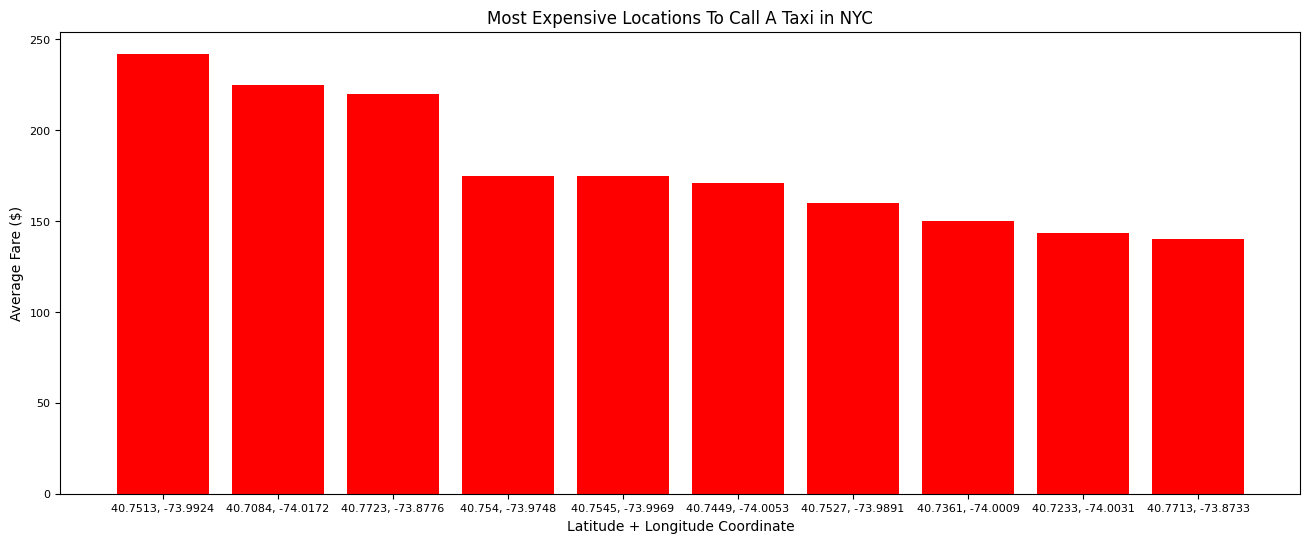

In [0]:
lat_and_long_fare_df = df.groupBy("lat_and_long").agg(mean("fare_amount").alias("avg_fare_amount"))
top_lat_and_long_fare_df = lat_and_long_fare_df.orderBy("avg_fare_amount", ascending=False).limit(10).toPandas()

top_lat_and_long_fare_df["lat_and_long"] = top_lat_and_long_fare_df["lat_and_long"].astype(str)

plt.figure(figsize=(16, 6))

plt.bar(top_lat_and_long_fare_df["lat_and_long"], top_lat_and_long_fare_df["avg_fare_amount"], color="red")
plt.title("Most Expensive Locations To Call A Taxi in NYC")
plt.xlabel("Latitude + Longitude Coordinate")
plt.ylabel("Average Fare ($)")
plt.xticks(size=8)
plt.yticks(size=8)

plt.show()

### 7. Correlation Analysis

In [0]:
df.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'pickup_longitude',
 'pickup_latitude',
 'RateCodeID',
 'store_and_fwd_flag',
 'dropoff_longitude',
 'dropoff_latitude',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'trip_duration_exact',
 'trip_duration_mins',
 'trip_speed_mph',
 'pickup_day',
 'pickup_hour',
 'pickup_year',
 'lat_and_long',
 'lat_and_long_dropoff']

Key features include:
`passenger_count`,
`duration_in_mins`,
`trip_distance`,
`fare_amount`,
`extra`

Steps
1. Perform a heatmap correlation analysis between them
2. Explore the notable  ones in further detail

In [0]:
p_df = df.toPandas()
p_df[['passenger_count', 'trip_duration_mins', 'trip_distance', 'fare_amount', 'extra']].dtypes


passenger_count       object
trip_duration_mins     int32
trip_distance         object
fare_amount           object
extra                 object
dtype: object

In [0]:
p_df[['passenger_count', 'trip_duration_mins', 'trip_distance', 'fare_amount', 'extra']] = p_df[['passenger_count', 'trip_duration_mins', 'trip_distance', 'fare_amount', 'extra']].astype(float).astype(int)

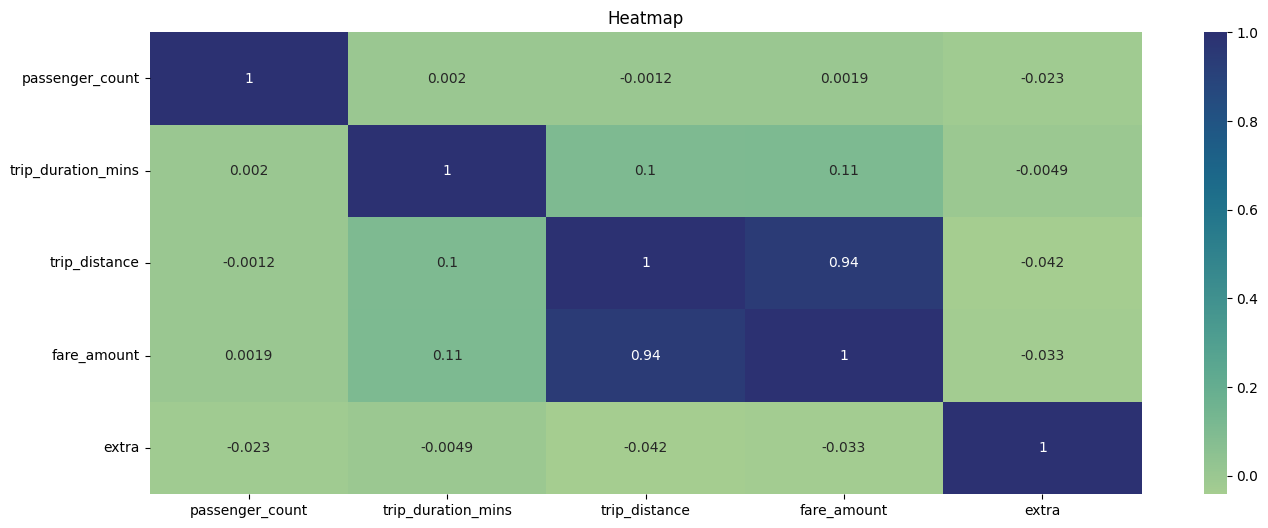

In [0]:
plt.figure(figsize=(16, 6))
sns.heatmap(p_df[['passenger_count', 'trip_duration_mins', 'trip_distance', 'fare_amount', 'extra']].corr(), annot=True, cmap="crest")

plt.title("Heatmap")
plt.show()

As expected, fare_amount and trip_distance have an extremely high correlation. Apart from those, duration, distance, and the fare amount are not nearly as correlated as we might expect.

One possible reason for explaning why distance and duration may have a lower correlation than expected is traffic. In a busy city like NYC, there is a lot of noise or randomness in how long your trip takes.

A reason for why fare amount may have a lower correlation with the two than expected may be due to taxi base fees, as well as different taxi services having different prices, in addition to time of day also playing a role.

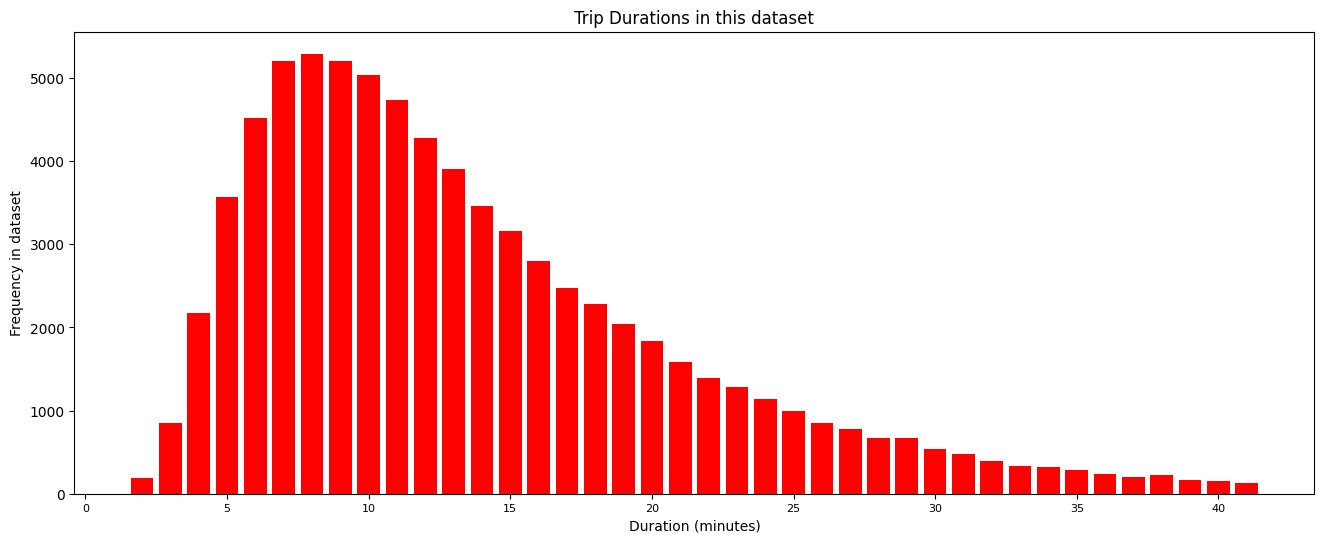

In [0]:
duration_df = p_df["trip_duration_mins"].value_counts(ascending=False).head(40)
plt.figure(figsize=(16, 6))
plt.bar(duration_df.index, duration_df, color="red")
plt.title("Trip Durations in this dataset")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency in dataset")
plt.xticks(size=8)

plt.show()

This theory of base fees having a higher impact than expected is further supported by the right-skewed graph above. Most trips are short in our dataset, and thus base fees may play a more important role in fare prices, with distance and direction playing a less important role in this dataset regarding correlation to the fare price.

### 8. Seasonality Detection

In [0]:
df = df.withColumn("pickup_month", month("tpep_pickup_datetime").cast("int"))

#Seasonality code
#This ended up not working well, because the data does not have seasons beyond winter
#It even says this in the Kaggle dataset after I checked it: "Jan 2015 & Jan-mar 2016."
# df = df.withColumn(
#     "pickup_season",
#     when((col("pickup_month") <= 2) | ((col("pickup_month") == 3) & (col("pickup_day") <= 19)), "Winter")
#     .when((col("pickup_month") <= 4) | ((col("pickup_month") == 5) & (col("pickup_day") <= 19)), "Spring")
#     .when((col("pickup_month") <= 8) | ((col("pickup_month") == 9) & (col("pickup_day") <= 21)), "Summer")
#     .otherwise("Fall")
# )

month_df = df.select("pickup_month").toPandas()

In [0]:
month_df_vcs = month_df.value_counts()

In [0]:
month_df_vcs

pickup_month
1               39019
2               19591
3               18687
dtype: int64

In [0]:
month_df_vcs.index = ["January", "February", "March"]

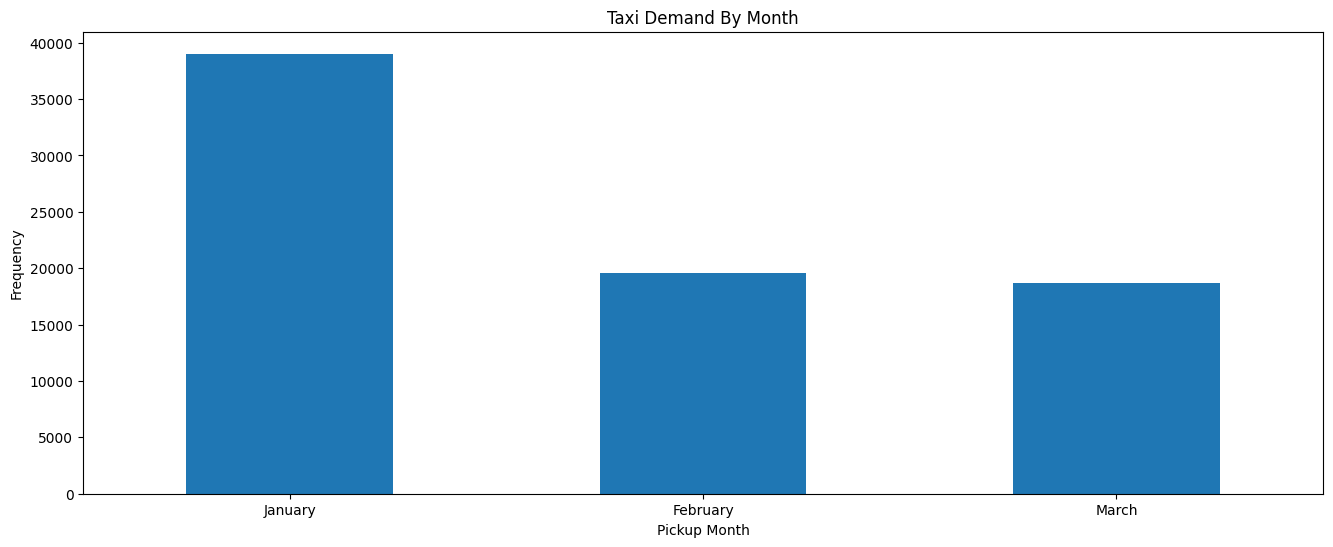

In [0]:
plt.figure(figsize=(16, 6))
month_df_vcs.plot(kind="bar")
plt.xlabel("Pickup Month")
plt.ylabel("Frequency")
plt.title("Taxi Demand By Month")
plt.xticks(rotation=0)
plt.show()

In [0]:
month_df_vcs

January     39019
February    19591
March       18687
dtype: int64